# 02 · Conformal prediction in five lines
We follow Angelopoulos & Bates (2022). Conformal prediction turns *any* model's heuristic confidence into **prediction sets with a coverage guarantee**: the true label is inside the set with probability ≥ 1 − α — *no distributional assumptions*, as long as calibration and test data are **exchangeable**.

Here the label is the 5-class disease-severity target (0 none · 1 mild · 2 moderate · 3 severe · 4 critical), so a prediction set is any *subset* of those five classes, e.g. `{No disease, Mild}`.

In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## A model to be uncertain about
We train a softmax model on Cleveland (chosen automatically for K > 2 classes) and hold out half of it for calibration.

In [2]:
sd = sites['cleveland']
rng = np.random.default_rng(0)
idx = rng.permutation(sd.n)
tr, cal, te = idx[:120], idx[120:210], idx[210:]
model = federated.make_model(sd.X.shape[1], sd.n_classes)
model = federated.local_train(model, sd.X[tr], sd.y[tr], epochs=300)
cal_probs, cal_y = model.predict_proba(sd.X[cal]), sd.y[cal]
test_probs, test_y = model.predict_proba(sd.X[te]), sd.y[te]
print('classes:', sd.class_names)
print('calibration points:', len(cal_y))

classes: ['No disease', 'Mild', 'Moderate', 'Severe', 'Critical']
calibration points: 90


## The calibration step
The nonconformity score is `s = 1 − f(x)_y` (large when the model is confidently wrong). We take a finite-sample-corrected quantile `q̂` of the calibration scores.

q̂ = 0.952


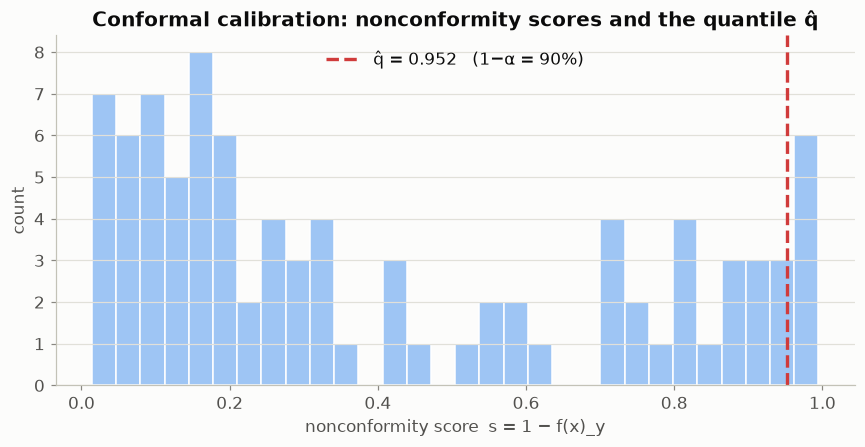

In [3]:
alpha = 0.1
scores = conformal.lac_scores(cal_probs, cal_y)
qhat = conformal.conformal_quantile(scores, alpha)
print(f'q̂ = {qhat:.3f}')
viz.plot_calibration_scores(scores, qhat, alpha);

## Forming prediction sets and checking coverage
A label is kept in the set when `1 − f(x)_y ≤ q̂`.

In [4]:
cp = conformal.LACPredictor(alpha=alpha).calibrate(cal_probs, cal_y)
sets = cp.predict_set(test_probs)
res = ev.evaluate_all(sets, test_y)
print(f"coverage = {res['coverage']:.3f}  (target {1-alpha:.2f})")
print(f"avg set size = {res['avg_set_size']:.2f}")

coverage = 0.903  (target 0.90)
avg set size = 3.09


## Correctness check
Any single split fluctuates. Averaged over many random calibration/test splits, coverage should sit right on 1 − α. This is how you *verify* a conformal implementation (paper §3.3).

In [5]:
covs = []
for seed in range(200):
    r = np.random.default_rng(seed).permutation(sd.n)
    c, t = r[:150], r[150:]
    cpp = conformal.LACPredictor(alpha=alpha).calibrate(model.predict_proba(sd.X[c]), sd.y[c])
    covs.append(ev.coverage(cpp.predict_set(model.predict_proba(sd.X[t])), sd.y[t]))
print(f'mean coverage over 200 splits = {np.mean(covs):.3f}')

mean coverage over 200 splits = 0.902

## Adaptive Prediction Sets (APS)
LAC gives the smallest sets but can under-cover hard cases. APS (Eq. 3) accumulates softmax mass and adapts set size to difficulty. Try it and compare average set size.

In [6]:
aps = conformal.APSPredictor(alpha=alpha, seed=0).calibrate(cal_probs, cal_y)
aps_sets = aps.predict_set(test_probs)
print('APS coverage   =', round(ev.coverage(aps_sets, test_y), 3))
print('APS avg size   =', round(ev.average_set_size(aps_sets), 2))
print('LAC avg size   =', round(res['avg_set_size'], 2))

APS coverage   = 0.903
APS avg size   = 2.96
LAC avg size   = 3.09


### Exercise
Change `alpha` to 0.05 and 0.2. How do `q̂`, coverage and average set size respond? Explain the trade-off between coverage and set size to a colleague in one sentence.